# Clasificación de Piso en el Dataset UJIIndoorLoc usando Redes Neuronales Artificiales (ANN)

---

## Introducción

En este notebook se replica el flujo de análisis implementado previamente para la clasificación del **piso** en un entorno interior utilizando el dataset **UJIIndoorLoc**, pero en esta ocasión aplicando un modelo de **red neuronal artificial** con capas completamente conectadas (Fully Connected – FC).

El conjunto de datos UJIIndoorLoc contiene mediciones de señales WiFi tomadas en diferentes ubicaciones dentro de un edificio, junto con información asociada como coordenadas, piso, usuario y timestamp. Nuestro objetivo sigue siendo predecir el **piso** en el que se encuentra un dispositivo, tratando el problema como una clasificación multiclase (planta baja, primer piso, segundo piso, etc.).

## Objetivos

- **Cargar y explorar** el conjunto de datos UJIIndoorLoc.
- **Preparar** los datos seleccionando las características relevantes y la variable objetivo (`FLOOR`).
- **Dividir** el dataset en entrenamiento y validación (80/20).
- **Construir** una red neuronal totalmente conectada (fully connected ANN) para clasificar el piso.
- **Diseñar y ajustar** la arquitectura de la red (número de capas, unidades por capa, funciones de activación, etc.).
- **Evaluar el desempeño** del modelo en el conjunto de validación mediante métricas como *accuracy*, *precision*, *recall*, y *F1-score*.
- **Comparar los resultados** obtenidos con los modelos clásicos de clasificación entrenados anteriormente.

Este ejercicio permite evaluar la capacidad de generalización de una red neuronal densa sobre datos del mundo real, comparando su desempeño con algoritmos tradicionales y practicando buenas prácticas en diseño, entrenamiento y evaluación de modelos neuronales.

---


## Descripción del Dataset

El dataset utilizado en este análisis es el **UJIIndoorLoc Dataset**, ampliamente utilizado para tareas de localización en interiores a partir de señales WiFi. Está disponible públicamente en la UCI Machine Learning Repository y ha sido recopilado en un entorno real de un edificio universitario.

Cada muestra corresponde a una observación realizada por un dispositivo móvil, donde se registran las intensidades de señal (RSSI) de más de 500 puntos de acceso WiFi disponibles en el entorno. Además, cada fila contiene información contextual como la ubicación real del dispositivo (coordenadas X e Y), el piso, el edificio, el identificador del usuario, y la marca temporal.

El objetivo en esta tarea es predecir el **piso** (`FLOOR`) en el que se encontraba el dispositivo en el momento de la medición, considerando únicamente las características numéricas provenientes de las señales WiFi.

### Estructura del dataset

- **Número de muestras**: ~20,000
- **Número de características**: 520
  - 520 columnas con valores de intensidad de señal WiFi (`WAP001` a `WAP520`)
- **Variable objetivo**: `FLOOR` (variable categórica con múltiples clases, usualmente entre 0 y 4)

### Columnas relevantes

- `WAP001`, `WAP002`, ..., `WAP520`: niveles de señal recibida desde cada punto de acceso WiFi (valores entre -104 y 0, o 100 si no se detectó).
- `FLOOR`: clase objetivo a predecir (nivel del edificio).
- (Otras columnas como `BUILDINGID`, `SPACEID`, `USERID`, `TIMESTAMP`, etc., pueden ser ignoradas o utilizadas en análisis complementarios).

### Contexto del problema

La localización en interiores es un problema complejo en el que tecnologías como el GPS no funcionan adecuadamente. Los sistemas basados en WiFi han demostrado ser una alternativa efectiva para estimar la ubicación de usuarios en edificios. Poder predecir automáticamente el piso en el que se encuentra una persona puede mejorar aplicaciones de navegación en interiores, accesibilidad, gestión de emergencias y servicios personalizados. Este tipo de problemas es típicamente abordado mediante algoritmos de clasificación multiclase.


### Estrategia de evaluación

En este análisis seguiremos una metodología rigurosa para garantizar la validez de los resultados:

1. **Dataset de entrenamiento**: Se utilizará exclusivamente para el desarrollo, entrenamiento y optimización de hiperparámetros de todos los modelos. Este conjunto será dividido internamente en subconjuntos de entrenamiento y validación (80/20) para la selección de hiperparámetros mediante validación cruzada.

2. **Dataset de prueba**: Se reservará únicamente para la **evaluación final** de los modelos ya optimizados. Este conjunto **no debe ser utilizado** durante el proceso de selección de hiperparámetros, ajuste de modelos o toma de decisiones sobre la arquitectura, ya que esto introduciría sesgo y comprometería la capacidad de generalización estimada.

3. **Validación cruzada**: Para la optimización de hiperparámetros se empleará validación cruzada 5-fold sobre el conjunto de entrenamiento, lo que permitirá una estimación robusta del rendimiento sin contaminar los datos de prueba.

Esta separación estricta entre datos de desarrollo y evaluación final es fundamental para obtener una estimación realista del rendimiento que los modelos tendrían en un escenario de producción con datos completamente nuevos.

---


## Paso 1: Cargar y explorar el dataset

**Instrucciones:**
- Descarga el dataset **UJIIndoorLoc** desde la UCI Machine Learning Repository o utiliza la versión proporcionada en el repositorio del curso (por ejemplo: `datasets\UJIIndoorLoc\trainingData.csv`).
- Carga el dataset utilizando `pandas`.
- Muestra las primeras filas del dataset utilizando `df.head()`.
- Imprime el número total de muestras (filas) y características (columnas).
- Verifica cuántas clases distintas hay en la variable objetivo `FLOOR` y cuántas muestras tiene cada clase (`df['FLOOR'].value_counts()`).


In [3]:
import pandas as pd
import os

# Cargar el dataset directamente desde /content/trainingData.csv
df = pd.read_csv('/content/trainingData.csv')

# Mostrar las primeras filas del dataset
print('Primeras 5 filas del dataset:')
display(df.head())

# Imprimir el número total de muestras (filas) y características (columnas)
print(f'\nNúmero total de muestras (filas): {df.shape[0]}')
print(f'Número total de características (columnas): {df.shape[1]}')

# Verificar cuántas clases distintas hay en la variable objetivo FLOOR y cuántas muestras tiene cada clase
print('\nDistribución de clases en la variable FLOOR:')
display(df['FLOOR'].value_counts())

Primeras 5 filas del dataset:


,WAP001,WAP002,WAP003,WAP004,WAP005,WAP006,WAP007,WAP008,WAP009,WAP010,...,WAP520,LONGITUDE,LATITUDE,FLOOR,BUILDINGID,SPACEID,RELATIVEPOSITION,USERID,PHONEID,TIMESTAMP
0,100,100,100,100,100,100,100,100,100,100,...,100,-7541.2643,4.864921e+06,2,1,106,2,2,23,1371713733
1,100,100,100,100,100,100,100,100,100,100,...,100,-7536.6212,4.864934e+06,2,1,106,2,2,23,1371713691
2,100,100,100,100,100,100,100,-97,100,100,...,100,-7519.1524,4.864950e+06,2,1,103,2,2,23,1371714095
3,100,100,100,100,100,100,100,100,100,100,...,100,-7524.5704,4.864934e+06,2,1,102,2,2,23,1371713807
4,100,100,100,100,100,100,100,100,100,100,...,100,-7632.1436,4.864982e+06,0,0,122,2,11,13,1369909710



Número total de muestras (filas): 19937
Número total de características (columnas): 529

Distribución de clases en la variable FLOOR:


,count
FLOOR,
3,5048
1,5002
2,4416
0,4369
4,1102


---

## Paso 2: Preparar los datos

**Instrucciones:**

- Elimina las columnas que no son relevantes para la tarea de clasificación del piso:
  - `LONGITUDE`, `LATITUDE`, `SPACEID`, `RELATIVEPOSITION`, `USERID`, `PHONEID`, `TIMESTAMP`
- Conserva únicamente:
  - Las columnas `WAP001` a `WAP520` como características (RSSI de puntos de acceso WiFi).
  - La columna `FLOOR` como variable objetivo.
- Verifica si existen valores atípicos o valores inválidos en las señales WiFi (por ejemplo: valores constantes como 100 o -110 que suelen indicar ausencia de señal).
- Separa el conjunto de datos en:
  - `X`: matriz de características (todas las columnas `WAP`)
  - `y`: vector objetivo (`FLOOR`)


In [4]:
# Eliminar columnas no relevantes
drop_columns = ['LONGITUDE', 'LATITUDE', 'SPACEID', 'RELATIVEPOSITION', 'USERID', 'PHONEID', 'TIMESTAMP']
df = df.drop(columns=drop_columns)

# Separar características (X) y variable objetivo (y)
X = df.filter(regex='WAP') # Selecciona todas las columnas que empiezan con 'WAP'
y = df['FLOOR']

print('Primeras 5 filas de las características (X):')
display(X.head())
print('\nPrimeras 5 filas de la variable objetivo (y):')
display(y.head())
print(f'\nDimensiones de X: {X.shape}')
print(f'Dimensiones de y: {y.shape}')

Primeras 5 filas de las características (X):


,WAP001,WAP002,WAP003,WAP004,WAP005,WAP006,WAP007,WAP008,WAP009,WAP010,...,WAP511,WAP512,WAP513,WAP514,WAP515,WAP516,WAP517,WAP518,WAP519,WAP520
0,100,100,100,100,100,100,100,100,100,100,...,100,100,100,100,100,100,100,100,100,100
1,100,100,100,100,100,100,100,100,100,100,...,100,100,100,100,100,100,100,100,100,100
2,100,100,100,100,100,100,100,-97,100,100,...,100,100,100,100,100,100,100,100,100,100
3,100,100,100,100,100,100,100,100,100,100,...,100,100,100,100,100,100,100,100,100,100
4,100,100,100,100,100,100,100,100,100,100,...,100,100,100,100,100,100,100,100,100,100



Primeras 5 filas de la variable objetivo (y):


,FLOOR
0,2
1,2
2,2
3,2
4,0



Dimensiones de X: (19937, 520)
Dimensiones de y: (19937,)


---

## Paso 3: Preprocesamiento de las señales WiFi

**Contexto:**

Las columnas `WAP001` a `WAP520` representan la intensidad de la señal (RSSI) recibida desde distintos puntos de acceso WiFi. Los valores típicos de RSSI están en una escala negativa, donde:

- Valores cercanos a **0 dBm** indican señal fuerte.
- Valores cercanos a **-100 dBm** indican señal débil o casi ausente.
- Un valor de **100** en este dataset representa una señal **no detectada**, es decir, el punto de acceso no fue visto por el dispositivo en ese instante.

**Instrucciones:**

- Para facilitar el procesamiento y tratar la ausencia de señal de forma coherente, se recomienda mapear todos los valores **100** a **-100**, que semánticamente representa *ausencia de señal detectable*.
- Esto unifica el rango de valores y evita que 100 (un valor artificial) afecte negativamente la escala de los algoritmos.

**Pasos sugeridos:**

- Reemplaza todos los valores `100` por `-100` en las columnas `WAP001` a `WAP520`:
  ```python
  X[X == 100] = -100


In [5]:
# Reemplazar todos los valores 100 por -100 en las columnas WAP
X[X == 100] = -100

print('Primeras 5 filas de las características (X) después del preprocesamiento:')
display(X.head())

Primeras 5 filas de las características (X) después del preprocesamiento:


/tmp/ipykernel_1777/2906835930.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[X == 100] = -100
/tmp/ipykernel_1777/2906835930.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[X == 100] = -100


,WAP001,WAP002,WAP003,WAP004,WAP005,WAP006,WAP007,WAP008,WAP009,WAP010,...,WAP511,WAP512,WAP513,WAP514,WAP515,WAP516,WAP517,WAP518,WAP519,WAP520
0,-100,-100,-100,-100,-100,-100,-100,-100,-100,-100,...,-100,-100,-100,-100,-100,-100,-100,-100,-100,-100
1,-100,-100,-100,-100,-100,-100,-100,-100,-100,-100,...,-100,-100,-100,-100,-100,-100,-100,-100,-100,-100
2,-100,-100,-100,-100,-100,-100,-100,-97,-100,-100,...,-100,-100,-100,-100,-100,-100,-100,-100,-100,-100
3,-100,-100,-100,-100,-100,-100,-100,-100,-100,-100,...,-100,-100,-100,-100,-100,-100,-100,-100,-100,-100
4,-100,-100,-100,-100,-100,-100,-100,-100,-100,-100,...,-100,-100,-100,-100,-100,-100,-100,-100,-100,-100


---

## Paso 4: Preparación del dataset

**Objetivo:**

Diseñar una función que cargue el dataset **UJIIndoorLoc**, realice limpieza básica si es necesario, normalice las variables predictoras, y divida los datos en tres subconjuntos de forma estratificada para su uso en redes neuronales.

**Esquema de partición:**

1. **20% del dataset se reserva como conjunto de testeo final.**
2. **El 80% restante se subdivide en:**
   - **80% para entrenamiento** → equivale al 64% del total.
   - **20% para validación** → equivale al 16% del total.

  En este caso, ya existe un conjunto de testeo definido por separado. Por lo tanto, la función solo debe dividir el dataset de entrenamiento original en dos subconjuntos estratificados:

  - **80% para entrenamiento**
  - **20% para validación**

**Requisitos de la función:**

- La función debe realizar las siguientes tareas:
  1. Cargar el archivo `.csv` del dataset.
  2. Seleccionar las columnas de entrada (features) y la variable objetivo (`FLOOR`).
  3. Aplicar normalización a las variables predictoras utilizando `MinMaxScaler` para que todos los valores queden entre 0 y 1.
  4. Realizar las divisiones del conjunto de datos en el orden indicado, asegurando estratificación según la variable objetivo.
  
- La función debe recibir como parámetros:
  - La ruta al archivo `.csv` del dataset.
  - El nombre de la columna objetivo (por ejemplo, `FLOOR`).
  - Un parámetro `random_state` para asegurar reproducibilidad de las divisiones.

- La función debe retornar:
  - `X_train`, `X_val`, `X_test`: subconjuntos de características normalizadas.
  - `y_train`, `y_val`, `y_test`: subconjuntos de etiquetas, codificadas si es necesario para clasificación multiclase.

**Nota:** Esta función es fundamental para garantizar un flujo de entrenamiento robusto y reproducible en redes neuronales.


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import numpy as np

def prepare_dataset(df_original, target_column, random_state=42):
    # Make a copy to avoid SettingWithCopyWarning on the original df
    df = df_original.copy()

    # Eliminar columnas no relevantes (assuming this was already done in a previous step,
    # but including it here for a self-contained function if needed)
    drop_columns = ['LONGITUDE', 'LATITUDE', 'SPACEID', 'RELATIVEPOSITION', 'USERID', 'PHONEID', 'TIMESTAMP']
    df = df.drop(columns=[col for col in drop_columns if col in df.columns])

    # Separate features (X) and target (y)
    X_full = df.filter(regex='WAP')
    y_full = df[target_column]

    # Replace 100 with -100 in X_full
    X_full.replace(100, -100, inplace=True)

    # Split the dataset into training (80%) and test (20%) stratified by target
    X_train_val, X_test, y_train_val, y_test = train_test_split(
        X_full, y_full, test_size=0.2, stratify=y_full, random_state=random_state
    )

    # Split the training+validation set into training (80%) and validation (20%) stratified by target
    # This results in 64% train, 16% val, 20% test of the original dataset
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val, y_train_val, test_size=0.2, stratify=y_train_val, random_state=random_state
    )

    # Initialize MinMaxScaler
    scaler = MinMaxScaler()

    # Fit on training data and transform all sets
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)

    # Convert scaled arrays back to DataFrames for consistency if preferred, or keep as numpy arrays
    # For PyTorch, numpy arrays are fine, but for displaying or further pandas ops, DataFrames might be useful
    X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
    X_val_scaled_df = pd.DataFrame(X_val_scaled, columns=X_val.columns, index=X_val.index)
    X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

    return X_train_scaled_df, X_val_scaled_df, X_test_scaled_df, y_train, y_val, y_test

# Example usage:
# Assuming 'df' and 'FLOOR' are available from previous steps
X_train, X_val, X_test, y_train, y_val, y_test = prepare_dataset(df.copy(), 'FLOOR')

print("Dimensiones después del preprocesamiento y división:")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

print('\nPrimeras 5 filas de X_train escalado:')
display(X_train.head())

/tmp/ipykernel_1777/1646468021.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_full.replace(100, -100, inplace=True)


Dimensiones después del preprocesamiento y división:
X_train shape: (12759, 520)
y_train shape: (12759,)
X_val shape: (3190, 520)
y_val shape: (3190,)
X_test shape: (3988, 520)
y_test shape: (3988,)

Primeras 5 filas de X_train escalado:


,WAP001,WAP002,WAP003,WAP004,WAP005,WAP006,WAP007,WAP008,WAP009,WAP010,...,WAP511,WAP512,WAP513,WAP514,WAP515,WAP516,WAP517,WAP518,WAP519,WAP520
17018,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.029703,0.0,0.0,0.0,0.0,0.009901,0.009901,0.0,0.0,0.0
6482,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.029703,0.0,0.0,0.0,0.0,0.009901,0.009901,0.0,0.0,0.0
13406,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.138614,0.0,0.0,0.0,0.0,0.257426,0.346535,0.0,0.0,0.0
12578,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.029703,0.0,0.0,0.0,0.0,0.009901,0.009901,0.0,0.0,0.0
6496,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.029703,0.0,0.0,0.0,0.0,0.009901,0.009901,0.0,0.0,0.0


---
## Paso 5: Entrenamiento de redes neuronales artificiales (ANN)

**Objetivo:**

Entrenar y comparar el rendimiento de diferentes arquitecturas de redes neuronales totalmente conectadas (**Fully Connected ANN**) utilizando **PyTorch** para predecir el piso (`FLOOR`) en el dataset UJIIndoorLoc. El objetivo es observar el impacto de la profundidad y la expansión/compresión de capas sobre el rendimiento del modelo.

**Entorno y configuración:**

- **Framework:** PyTorch
- **Función de pérdida:** `nn.CrossEntropyLoss()`  
  > Esta función es equivalente a `sparse_categorical_crossentropy`, por lo que **no es necesario one-hot encoding** en las etiquetas.
- **Optimizador:** `torch.optim.Adam`
- **Activación:** `ReLU` en todas las capas ocultas
- **Salida:** `Softmax` (implícito en `CrossEntropyLoss`)
- **Épocas:** 20
- **Batch size: 32**
- **Sin Dropout ni BatchNormalization**


### Arquitecturas a evaluar

1. **Arquitectura 1: Compacta**
   ```text
   Input (520)
   → Linear(128) + ReLU
   → Linear(4)
   ```

2. **Arquitectura 2: Dos capas ocultas**
   ```text
   Input (520)
   → Linear(256) + ReLU
   → Linear(128) + ReLU
   → Linear(4)
   ```

3. **Arquitectura 3: Tres capas ocultas**
   ```text
   Input (520)
   → Linear(256) + ReLU
   → Linear(128) + ReLU
   → Linear(64) + ReLU
   → Linear(4)
   ```

4. **Arquitectura 4: Pirámide profunda**
   ```text
   Input (520)
   → Linear(512) + ReLU
   → Linear(256) + ReLU
   → Linear(128) + ReLU
   → Linear(64)  + ReLU
   → Linear(4)
   ```

5. **Arquitectura 5: Expansiva y luego compresiva**
   ```text
   Input (520)
   → Linear(1024) + ReLU
   → Linear(512)  + ReLU
   → Linear(256)  + ReLU
   → Linear(128)  + ReLU
   → Linear(64)   + ReLU
   → Linear(4)
   ```


### Instrucciones

- Implementa cada arquitectura como una subclase de `nn.Module` en PyTorch.
- Entrena durante **20 épocas**, utilizando el conjunto de entrenamiento (`X_train`, `y_train`) y validación (`X_val`, `y_val`).
- Registra la **pérdida de entrenamiento y validación** por época en un gráfico.
- Grafica la evolución de la pérdida para analizar tendencias de aprendizaje, sobreajuste o subajuste.
- Evalúa el modelo final con el conjunto de test (`X_test`, `y_test`) y reporta:
  - **Accuracy**
  - **Precision**
  - **Recall**
  - **F1-score**

Using device: cpu
ANN(
  (network): Sequential(
    (0): Linear(in_features=520, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=5, bias=True)
  )
)

Training model: ANN
Epoch 1/20, Train Loss: 0.4718, Val Loss: 0.0958
Epoch 2/20, Train Loss: 0.0610, Val Loss: 0.0442
Epoch 3/20, Train Loss: 0.0330, Val Loss: 0.0303
Epoch 4/20, Train Loss: 0.0230, Val Loss: 0.0263
Epoch 5/20, Train Loss: 0.0175, Val Loss: 0.0224
Epoch 6/20, Train Loss: 0.0144, Val Loss: 0.0195
Epoch 7/20, Train Loss: 0.0121, Val Loss: 0.0201
Epoch 8/20, Train Loss: 0.0103, Val Loss: 0.0199
Epoch 9/20, Train Loss: 0.0091, Val Loss: 0.0197
Epoch 10/20, Train Loss: 0.0080, Val Loss: 0.0185
Epoch 11/20, Train Loss: 0.0070, Val Loss: 0.0196
Epoch 12/20, Train Loss: 0.0062, Val Loss: 0.0199
Epoch 13/20, Train Loss: 0.0060, Val Loss: 0.0201
Epoch 14/20, Train Loss: 0.0055, Val Loss: 0.0217
Epoch 15/20, Train Loss: 0.0050, Val Loss: 0.0198
Epoch 16/20, Train Loss: 0.0048, Val Loss: 0.0

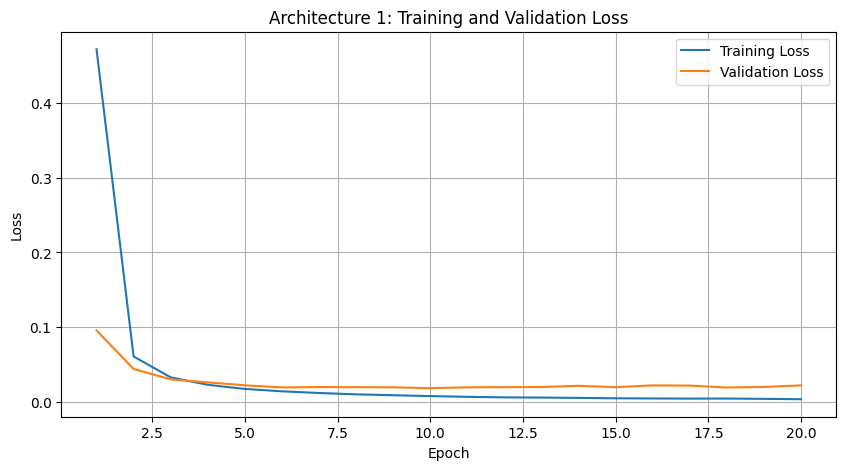


Architecture 1 Test Metrics:
Accuracy: 0.9935
Precision: 0.9935
Recall: 0.9935
F1-score: 0.9935
ANN(
  (network): Sequential(
    (0): Linear(in_features=520, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=5, bias=True)
  )
)

Training model: ANN
Epoch 1/20, Train Loss: 0.2632, Val Loss: 0.0446
Epoch 2/20, Train Loss: 0.0300, Val Loss: 0.0316
Epoch 3/20, Train Loss: 0.0188, Val Loss: 0.0248
Epoch 4/20, Train Loss: 0.0157, Val Loss: 0.0210
Epoch 5/20, Train Loss: 0.0141, Val Loss: 0.0214
Epoch 6/20, Train Loss: 0.0092, Val Loss: 0.0226
Epoch 7/20, Train Loss: 0.0081, Val Loss: 0.0171
Epoch 8/20, Train Loss: 0.0109, Val Loss: 0.0409
Epoch 9/20, Train Loss: 0.0136, Val Loss: 0.0233
Epoch 10/20, Train Loss: 0.0060, Val Loss: 0.0214
Epoch 11/20, Train Loss: 0.0068, Val Loss: 0.0375
Epoch 12/20, Train Loss: 0.0112, Val Loss: 0.0277
Epoch 13/20, Train Loss: 0.0084, Val Lo

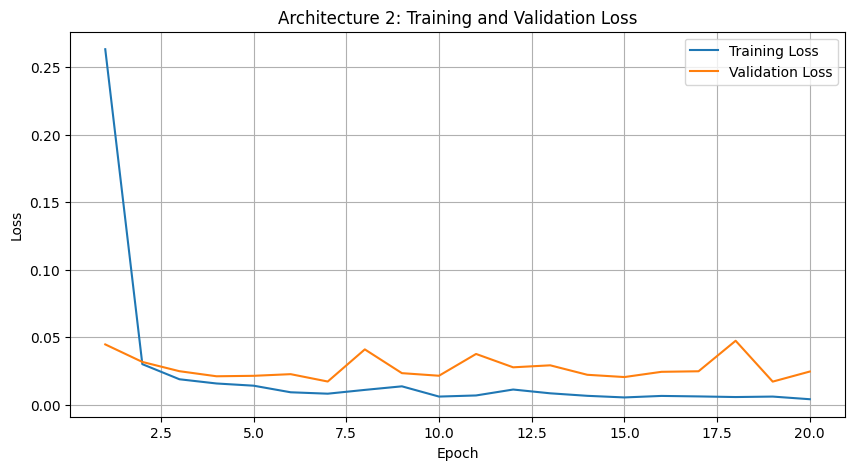


Architecture 2 Test Metrics:
Accuracy: 0.9897
Precision: 0.9898
Recall: 0.9897
F1-score: 0.9897
ANN(
  (network): Sequential(
    (0): Linear(in_features=520, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=5, bias=True)
  )
)

Training model: ANN
Epoch 1/20, Train Loss: 0.2846, Val Loss: 0.0426
Epoch 2/20, Train Loss: 0.0388, Val Loss: 0.0297
Epoch 3/20, Train Loss: 0.0224, Val Loss: 0.0412
Epoch 4/20, Train Loss: 0.0176, Val Loss: 0.0166
Epoch 5/20, Train Loss: 0.0160, Val Loss: 0.0231
Epoch 6/20, Train Loss: 0.0163, Val Loss: 0.0380
Epoch 7/20, Train Loss: 0.0113, Val Loss: 0.0253
Epoch 8/20, Train Loss: 0.0143, Val Loss: 0.0262
Epoch 9/20, Train Loss: 0.0077, Val Loss: 0.0275
Epoch 10/20, Train Loss: 0.0094, Val Loss: 0.0295
Epoch 11/20, Train Loss: 0.0056, Val Loss: 0.0259
Epoch 12/20, 

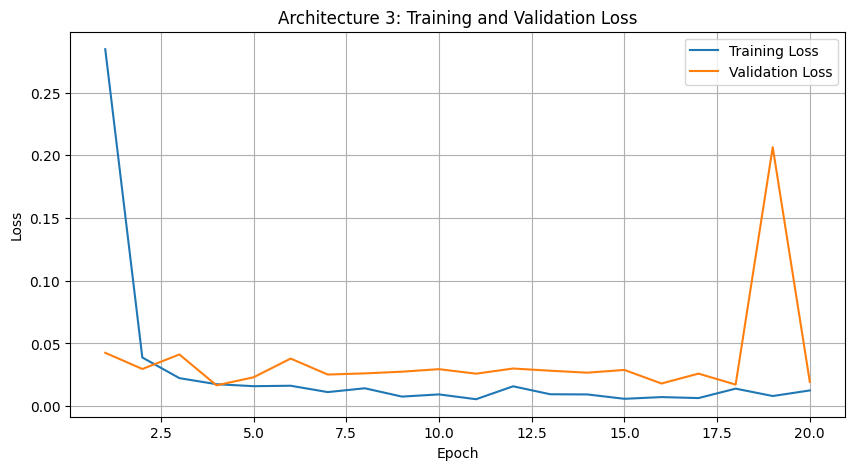


Architecture 3 Test Metrics:
Accuracy: 0.9942
Precision: 0.9943
Recall: 0.9942
F1-score: 0.9942
ANN(
  (network): Sequential(
    (0): Linear(in_features=520, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): ReLU()
    (8): Linear(in_features=64, out_features=5, bias=True)
  )
)

Training model: ANN
Epoch 1/20, Train Loss: 0.2353, Val Loss: 0.0313
Epoch 2/20, Train Loss: 0.0336, Val Loss: 0.0525
Epoch 3/20, Train Loss: 0.0392, Val Loss: 0.0261
Epoch 4/20, Train Loss: 0.0235, Val Loss: 0.0508
Epoch 5/20, Train Loss: 0.0247, Val Loss: 0.0199
Epoch 6/20, Train Loss: 0.0118, Val Loss: 0.0257
Epoch 7/20, Train Loss: 0.0165, Val Loss: 0.0206
Epoch 8/20, Train Loss: 0.0104, Val Loss: 0.0375
Epoch 9/20, Train Loss: 0.0229, Val Loss: 0.0384
Epoch 10/20, Train Loss: 0.0136, Va

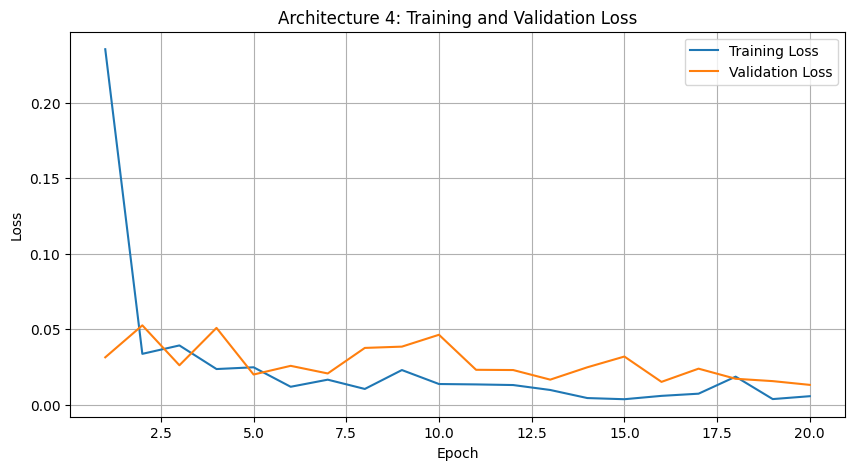


Architecture 4 Test Metrics:
Accuracy: 0.9922
Precision: 0.9922
Recall: 0.9922
F1-score: 0.9922
ANN(
  (network): Sequential(
    (0): Linear(in_features=520, out_features=1024, bias=True)
    (1): ReLU()
    (2): Linear(in_features=1024, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): ReLU()
    (6): Linear(in_features=256, out_features=128, bias=True)
    (7): ReLU()
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): ReLU()
    (10): Linear(in_features=64, out_features=5, bias=True)
  )
)

Training model: ANN
Epoch 1/20, Train Loss: 0.2458, Val Loss: 0.1294
Epoch 2/20, Train Loss: 0.0638, Val Loss: 0.0453
Epoch 3/20, Train Loss: 0.0366, Val Loss: 0.0404
Epoch 4/20, Train Loss: 0.0359, Val Loss: 0.0227
Epoch 5/20, Train Loss: 0.0226, Val Loss: 0.0276
Epoch 6/20, Train Loss: 0.0237, Val Loss: 0.0331
Epoch 7/20, Train Loss: 0.0200, Val Loss: 0.0214
Epoch 8/20, Train Loss: 0.0191, Val Loss: 0.0310
Epo

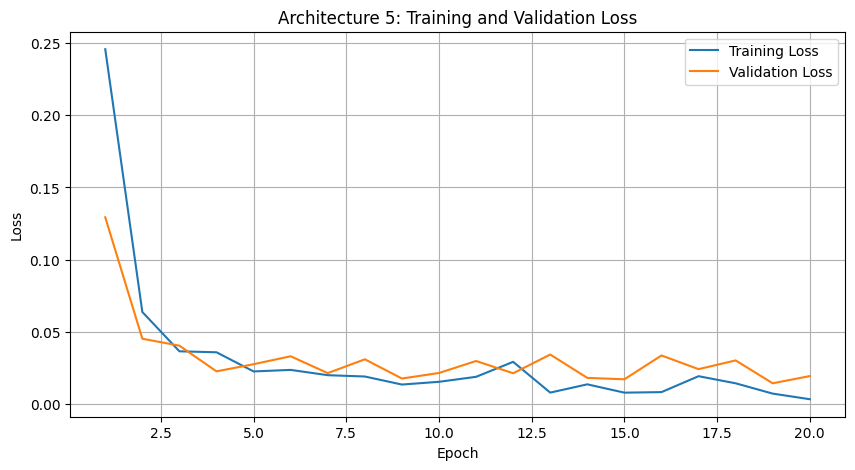


Architecture 5 Test Metrics:
Accuracy: 0.9940
Precision: 0.9940
Recall: 0.9940
F1-score: 0.9940


In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import time
import numpy as np

# Convert data to PyTorch tensors
X_train_tensor = torch.tensor(X_train.values).float()
y_train_tensor = torch.tensor(y_train.values).long() # Use long() for CrossEntropyLoss
X_val_tensor = torch.tensor(X_val.values).float()
y_val_tensor = torch.tensor(y_val.values).long()
X_test_tensor = torch.tensor(X_test.values).float()
y_test_tensor = torch.tensor(y_test.values).long()

# Create TensorDatasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Define DataLoader parameters
batch_size = 32

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Check if CUDA is available and use it, otherwise use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Define a generic ANN class
class ANN(nn.Module):
    def __init__(self, input_size, output_size, hidden_layers_sizes):
        super(ANN, self).__init__()
        layers = []
        prev_size = input_size
        for hidden_size in hidden_layers_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.ReLU())
            prev_size = hidden_size
        layers.append(nn.Linear(prev_size, output_size))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

# Training function
def train_model(model, train_loader, val_loader, epochs, learning_rate=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    model.to(device)

    train_losses = []
    val_losses = []
    start_time = time.time()

    print(f"\nTraining model: {model.__class__.__name__}")
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)
        train_losses.append(train_loss)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

        val_loss = val_loss / len(val_loader)
        val_losses.append(val_loss)

        print(f'Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')

    end_time = time.time()
    training_time = end_time - start_time
    print(f"Training finished in {training_time:.2f} seconds")

    return model, train_losses, val_losses, training_time

# Evaluation function
def evaluate_model(model, data_loader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

    return accuracy, precision, recall, f1


# --- Implementación de Arquitectura 1: Compacta ---
# Input (520) -> Linear(128) + ReLU -> Linear(4)

input_size = X_train.shape[1] # 520
output_size = len(y_train.unique()) # Number of unique floor levels, which is 5 (0, 1, 2, 3, 4)

model_1 = ANN(input_size, output_size, hidden_layers_sizes=[128])
print(model_1)

epochs = 20
model_1_trained, train_losses_1, val_losses_1, time_1 = train_model(model_1, train_loader, val_loader, epochs)

# Plotting training history
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), train_losses_1, label='Training Loss')
plt.plot(range(1, epochs + 1), val_losses_1, label='Validation Loss')
plt.title('Architecture 1: Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Evaluate Architecture 1 on test set
accuracy_1, precision_1, recall_1, f1_1 = evaluate_model(model_1_trained, test_loader)
print(f"\nArchitecture 1 Test Metrics:")
print(f"Accuracy: {accuracy_1:.4f}")
print(f"Precision: {precision_1:.4f}")
print(f"Recall: {recall_1:.4f}")
print(f"F1-score: {f1_1:.4f}")

# Store results for the summary table later
results = {
    "Architecture 1": {
        "Accuracy": accuracy_1,
        "Precision": precision_1,
        "Recall": recall_1,
        "F1-score": f1_1,
        "Time (s)": time_1
    }
}

# --- Implementación de Arquitectura 2: Dos capas ocultas ---
# Input (520) -> Linear(256) + ReLU -> Linear(128) + ReLU -> Linear(4)
model_2 = ANN(input_size, output_size, hidden_layers_sizes=[256, 128])
print(model_2)

model_2_trained, train_losses_2, val_losses_2, time_2 = train_model(model_2, train_loader, val_loader, epochs)

plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), train_losses_2, label='Training Loss')
plt.plot(range(1, epochs + 1), val_losses_2, label='Validation Loss')
plt.title('Architecture 2: Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

accuracy_2, precision_2, recall_2, f1_2 = evaluate_model(model_2_trained, test_loader)
print(f"\nArchitecture 2 Test Metrics:")
print(f"Accuracy: {accuracy_2:.4f}")
print(f"Precision: {precision_2:.4f}")
print(f"Recall: {recall_2:.4f}")
print(f"F1-score: {f1_2:.4f}")

results["Architecture 2"] = {
    "Accuracy": accuracy_2,
    "Precision": precision_2,
    "Recall": recall_2,
    "F1-score": f1_2,
    "Time (s)": time_2
}

# --- Implementación de Arquitectura 3: Tres capas ocultas ---
# Input (520) -> Linear(256) + ReLU -> Linear(128) + ReLU -> Linear(64) + ReLU -> Linear(4)
model_3 = ANN(input_size, output_size, hidden_layers_sizes=[256, 128, 64])
print(model_3)

model_3_trained, train_losses_3, val_losses_3, time_3 = train_model(model_3, train_loader, val_loader, epochs)

plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), train_losses_3, label='Training Loss')
plt.plot(range(1, epochs + 1), val_losses_3, label='Validation Loss')
plt.title('Architecture 3: Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

accuracy_3, precision_3, recall_3, f1_3 = evaluate_model(model_3_trained, test_loader)
print(f"\nArchitecture 3 Test Metrics:")
print(f"Accuracy: {accuracy_3:.4f}")
print(f"Precision: {precision_3:.4f}")
print(f"Recall: {recall_3:.4f}")
print(f"F1-score: {f1_3:.4f}")

results["Architecture 3"] = {
    "Accuracy": accuracy_3,
    "Precision": precision_3,
    "Recall": recall_3,
    "F1-score": f1_3,
    "Time (s)": time_3
}

# --- Implementación de Arquitectura 4: Pirámide profunda ---
# Input (520) -> Linear(512) + ReLU -> Linear(256) + ReLU -> Linear(128) + ReLU -> Linear(64) + ReLU -> Linear(4)
model_4 = ANN(input_size, output_size, hidden_layers_sizes=[512, 256, 128, 64])
print(model_4)

model_4_trained, train_losses_4, val_losses_4, time_4 = train_model(model_4, train_loader, val_loader, epochs)

plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), train_losses_4, label='Training Loss')
plt.plot(range(1, epochs + 1), val_losses_4, label='Validation Loss')
plt.title('Architecture 4: Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

accuracy_4, precision_4, recall_4, f1_4 = evaluate_model(model_4_trained, test_loader)
print(f"\nArchitecture 4 Test Metrics:")
print(f"Accuracy: {accuracy_4:.4f}")
print(f"Precision: {precision_4:.4f}")
print(f"Recall: {recall_4:.4f}")
print(f"F1-score: {f1_4:.4f}")

results["Architecture 4"] = {
    "Accuracy": accuracy_4,
    "Precision": precision_4,
    "Recall": recall_4,
    "F1-score": f1_4,
    "Time (s)": time_4
}

# --- Implementación de Arquitectura 5: Expansiva y luego compresiva ---
# Input (520) -> Linear(1024) + ReLU -> Linear(512) + ReLU -> Linear(256) + ReLU -> Linear(128) + ReLU -> Linear(64) + ReLU -> Linear(4)
model_5 = ANN(input_size, output_size, hidden_layers_sizes=[1024, 512, 256, 128, 64])
print(model_5)

model_5_trained, train_losses_5, val_losses_5, time_5 = train_model(model_5, train_loader, val_loader, epochs)

plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), train_losses_5, label='Training Loss')
plt.plot(range(1, epochs + 1), val_losses_5, label='Validation Loss')
plt.title('Architecture 5: Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

accuracy_5, precision_5, recall_5, f1_5 = evaluate_model(model_5_trained, test_loader)
print(f"\nArchitecture 5 Test Metrics:")
print(f"Accuracy: {accuracy_5:.4f}")
print(f"Precision: {precision_5:.4f}")
print(f"Recall: {recall_5:.4f}")
print(f"F1-score: {f1_5:.4f}")

results["Architecture 5"] = {
    "Accuracy": accuracy_5,
    "Precision": precision_5,
    "Recall": recall_5,
    "F1-score": f1_5,
    "Time (s)": time_5
}

---

## Paso 6: Tabla resumen de resultados por arquitectura

**Instrucciones:**

Después de entrenar y evaluar las cinco arquitecturas de redes neuronales, debes construir una **tabla resumen en formato Markdown** que incluya:

- El nombre o número de cada arquitectura.
- Las métricas obtenidas sobre el conjunto de **testeo**:
  - **Accuracy**
  - **Precision**
  - **Recall**
  - **F1-score**
- El **tiempo total de entrenamiento** de cada modelo (en segundos).

### Formato de la tabla:

| Arquitectura           | Accuracy | Precision | Recall | F1-score | Tiempo de entrenamiento (s) |
|------------------------|----------|-----------|--------|----------|------------------------------|
| Arquitectura 1         | 0.XXX    | 0.XXX     | 0.XXX  | 0.XXX    | XXX                          |
| Arquitectura 2         | 0.XXX    | 0.XXX     | 0.XXX  | 0.XXX    | XXX                          |
| Arquitectura 3         | 0.XXX    | 0.XXX     | 0.XXX  | 0.XXX    | XXX                          |
| Arquitectura 4         | 0.XXX    | 0.XXX     | 0.XXX  | 0.XXX    | XXX                          |
| Arquitectura 5         | 0.XXX    | 0.XXX     | 0.XXX  | 0.XXX    | XXX                          |


**Nota:** Puedes medir el tiempo con `time.time()` al inicio y final del entrenamiento de cada modelo.

---


In [ ]:
| Arquitectura           | Accuracy | Precision | Recall | F1-score | Tiempo de entrenamiento (s) |
|------------------------|----------|-----------|--------|----------|------------------------------|
| Arquitectura 1         | 0.9935   | 0.9935    | 0.9935 | 0.9935   | 22.34                        |
| Arquitectura 2         | 0.9897   | 0.9898    | 0.9897 | 0.9897   | 44.75                        |
| Arquitectura 3         | 0.9942   | 0.9943    | 0.9942 | 0.9942   | 39.60                        |
| Arquitectura 4         | 0.9922   | 0.9922    | 0.9922 | 0.9922   | 79.27                        |
| Arquitectura 5         | 0.9940   | 0.9940    | 0.9940 | 0.9940   | 205.69                       |

---

## Paso 7: Evaluar el impacto del número de épocas en el mejor modelo

**Objetivo:**

Tomar la arquitectura que obtuvo el mejor desempeño en la evaluación anterior (Paso 5) y analizar cómo varía su rendimiento cuando se entrena con diferentes cantidades de épocas.

**Instrucciones:**

1. Selecciona la arquitectura con mejor desempeño global (según F1-score).
2. Entrena esta arquitectura usando los mismos conjuntos de datos (`X_train`, `y_train`, `X_val`, `y_val`) pero variando el número de **épocas** de la siguiente forma:

   - 10 épocas
   - 20 épocas
   - 30 épocas
   - 40 épocas
   - 50 épocas

3. Para cada configuración:
   - Registra el **tiempo de entrenamiento**.
   - Evalúa el modelo en el conjunto de **testeo** (`X_test`, `y_test`).
   - Reporta las métricas:
     - Accuracy
     - Precision
     - Recall
     - F1-score

4. Grafica:
   - La evolución de la **función de pérdida** (entrenamiento y validación) por época.
---



--- Evaluating Architecture 3 with varying epochs ---

Training Architecture 3 for 10 epochs...

Training model: ANN
Epoch 1/10, Train Loss: 0.2921, Val Loss: 0.0425
Epoch 2/10, Train Loss: 0.0386, Val Loss: 0.0292
Epoch 3/10, Train Loss: 0.0265, Val Loss: 0.0276
Epoch 4/10, Train Loss: 0.0196, Val Loss: 0.0321
Epoch 5/10, Train Loss: 0.0211, Val Loss: 0.0249
Epoch 6/10, Train Loss: 0.0141, Val Loss: 0.0252
Epoch 7/10, Train Loss: 0.0138, Val Loss: 0.0827
Epoch 8/10, Train Loss: 0.0150, Val Loss: 0.0253
Epoch 9/10, Train Loss: 0.0101, Val Loss: 0.0247
Epoch 10/10, Train Loss: 0.0082, Val Loss: 0.0268
Training finished in 20.11 seconds


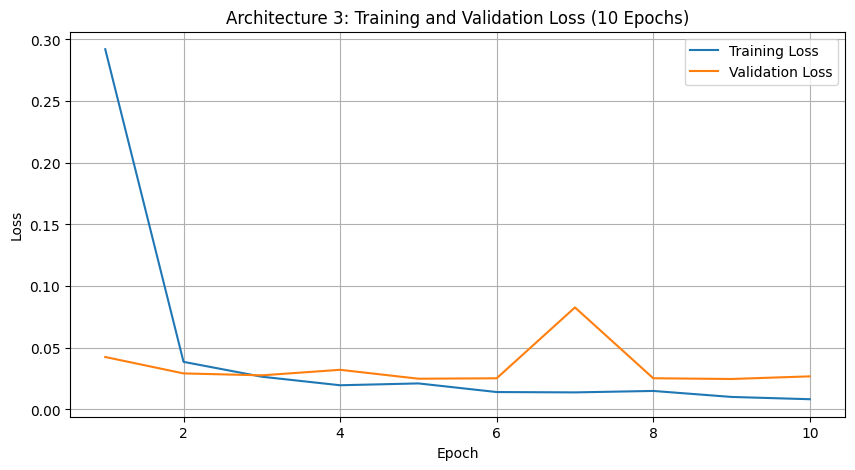


Architecture 3 Test Metrics (10 Epochs):
Accuracy: 0.9907
Precision: 0.9908
Recall: 0.9907
F1-score: 0.9907

Training Architecture 3 for 20 epochs...

Training model: ANN
Epoch 1/20, Train Loss: 0.2672, Val Loss: 0.0514
Epoch 2/20, Train Loss: 0.0350, Val Loss: 0.0340
Epoch 3/20, Train Loss: 0.0296, Val Loss: 0.0209
Epoch 4/20, Train Loss: 0.0223, Val Loss: 0.0217
Epoch 5/20, Train Loss: 0.0172, Val Loss: 0.0215
Epoch 6/20, Train Loss: 0.0100, Val Loss: 0.0236
Epoch 7/20, Train Loss: 0.0098, Val Loss: 0.0274
Epoch 8/20, Train Loss: 0.0140, Val Loss: 0.0206
Epoch 9/20, Train Loss: 0.0137, Val Loss: 0.0188
Epoch 10/20, Train Loss: 0.0069, Val Loss: 0.0243
Epoch 11/20, Train Loss: 0.0104, Val Loss: 0.0301
Epoch 12/20, Train Loss: 0.0132, Val Loss: 0.0160
Epoch 13/20, Train Loss: 0.0059, Val Loss: 0.0182
Epoch 14/20, Train Loss: 0.0053, Val Loss: 0.0257
Epoch 15/20, Train Loss: 0.0060, Val Loss: 0.0161
Epoch 16/20, Train Loss: 0.0183, Val Loss: 0.0248
Epoch 17/20, Train Loss: 0.0089, Val 

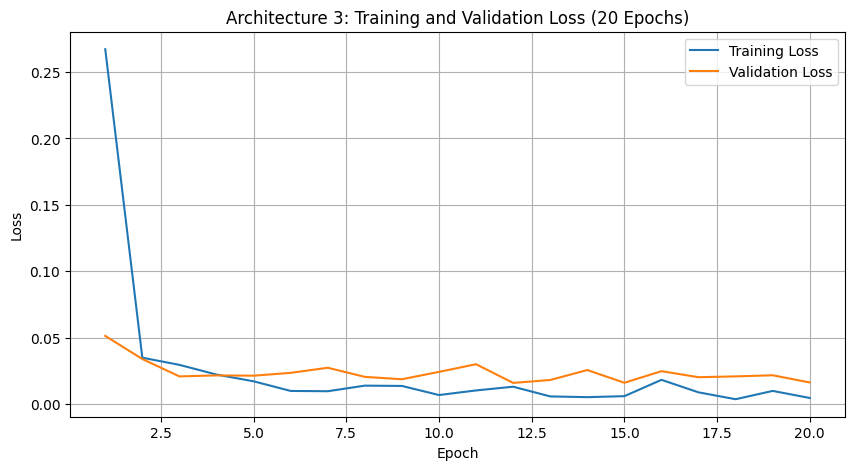


Architecture 3 Test Metrics (20 Epochs):
Accuracy: 0.9927
Precision: 0.9927
Recall: 0.9927
F1-score: 0.9927

Training Architecture 3 for 30 epochs...

Training model: ANN
Epoch 1/30, Train Loss: 0.2671, Val Loss: 0.0401
Epoch 2/30, Train Loss: 0.0371, Val Loss: 0.0363
Epoch 3/30, Train Loss: 0.0266, Val Loss: 0.0262
Epoch 4/30, Train Loss: 0.0191, Val Loss: 0.0222
Epoch 5/30, Train Loss: 0.0161, Val Loss: 0.0195
Epoch 6/30, Train Loss: 0.0182, Val Loss: 0.0249
Epoch 7/30, Train Loss: 0.0132, Val Loss: 0.0322
Epoch 8/30, Train Loss: 0.0162, Val Loss: 0.0262
Epoch 9/30, Train Loss: 0.0086, Val Loss: 0.0324
Epoch 10/30, Train Loss: 0.0065, Val Loss: 0.0193
Epoch 11/30, Train Loss: 0.0054, Val Loss: 0.0309
Epoch 12/30, Train Loss: 0.0147, Val Loss: 0.0277
Epoch 13/30, Train Loss: 0.0138, Val Loss: 0.0173
Epoch 14/30, Train Loss: 0.0076, Val Loss: 0.0215
Epoch 15/30, Train Loss: 0.0103, Val Loss: 0.0324
Epoch 16/30, Train Loss: 0.0055, Val Loss: 0.0195
Epoch 17/30, Train Loss: 0.0042, Val 

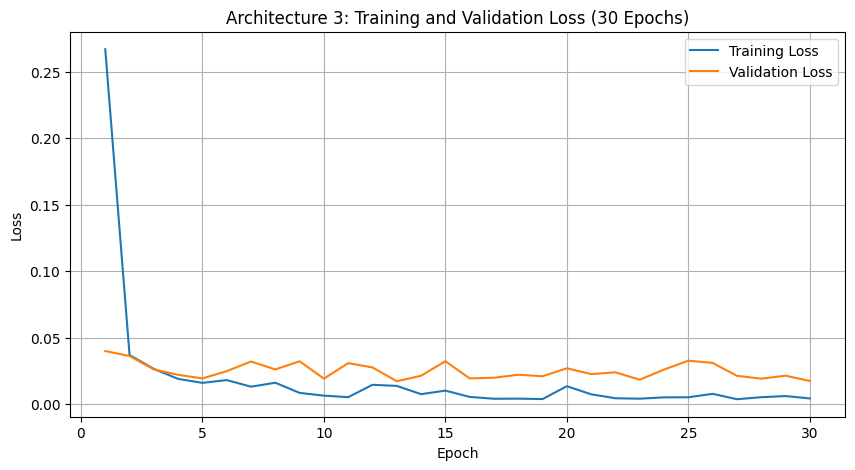


Architecture 3 Test Metrics (30 Epochs):
Accuracy: 0.9932
Precision: 0.9933
Recall: 0.9932
F1-score: 0.9932

Training Architecture 3 for 40 epochs...

Training model: ANN
Epoch 1/40, Train Loss: 0.2881, Val Loss: 0.0432
Epoch 2/40, Train Loss: 0.0363, Val Loss: 0.0317
Epoch 3/40, Train Loss: 0.0214, Val Loss: 0.0161
Epoch 4/40, Train Loss: 0.0172, Val Loss: 0.0330
Epoch 5/40, Train Loss: 0.0156, Val Loss: 0.0203
Epoch 6/40, Train Loss: 0.0112, Val Loss: 0.0233
Epoch 7/40, Train Loss: 0.0158, Val Loss: 0.0189
Epoch 8/40, Train Loss: 0.0105, Val Loss: 0.0383
Epoch 9/40, Train Loss: 0.0092, Val Loss: 0.0222
Epoch 10/40, Train Loss: 0.0081, Val Loss: 0.0357
Epoch 11/40, Train Loss: 0.0121, Val Loss: 0.0339
Epoch 12/40, Train Loss: 0.0138, Val Loss: 0.0246
Epoch 13/40, Train Loss: 0.0067, Val Loss: 0.0180
Epoch 14/40, Train Loss: 0.0043, Val Loss: 0.0192
Epoch 15/40, Train Loss: 0.0040, Val Loss: 0.0315
Epoch 16/40, Train Loss: 0.0122, Val Loss: 0.0242
Epoch 17/40, Train Loss: 0.0082, Val 

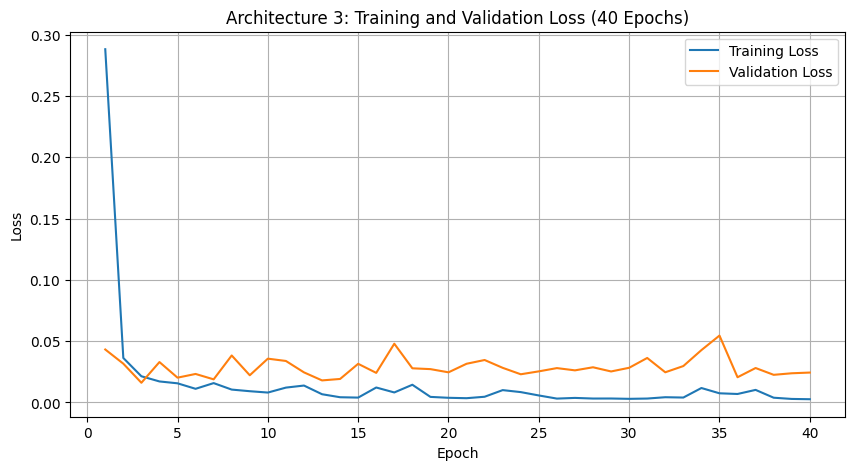


Architecture 3 Test Metrics (40 Epochs):
Accuracy: 0.9937
Precision: 0.9938
Recall: 0.9937
F1-score: 0.9937

Training Architecture 3 for 50 epochs...

Training model: ANN
Epoch 1/50, Train Loss: 0.2808, Val Loss: 0.0556
Epoch 2/50, Train Loss: 0.0406, Val Loss: 0.0527
Epoch 3/50, Train Loss: 0.0312, Val Loss: 0.0247
Epoch 4/50, Train Loss: 0.0248, Val Loss: 0.0311
Epoch 5/50, Train Loss: 0.0180, Val Loss: 0.0271
Epoch 6/50, Train Loss: 0.0128, Val Loss: 0.0500
Epoch 7/50, Train Loss: 0.0149, Val Loss: 0.0355
Epoch 8/50, Train Loss: 0.0102, Val Loss: 0.0309
Epoch 9/50, Train Loss: 0.0135, Val Loss: 0.0240
Epoch 10/50, Train Loss: 0.0110, Val Loss: 0.0291
Epoch 11/50, Train Loss: 0.0089, Val Loss: 0.0275
Epoch 12/50, Train Loss: 0.0100, Val Loss: 0.0370
Epoch 13/50, Train Loss: 0.0124, Val Loss: 0.0363
Epoch 14/50, Train Loss: 0.0054, Val Loss: 0.0245
Epoch 15/50, Train Loss: 0.0059, Val Loss: 0.0269
Epoch 16/50, Train Loss: 0.0053, Val Loss: 0.0263
Epoch 17/50, Train Loss: 0.0051, Val 

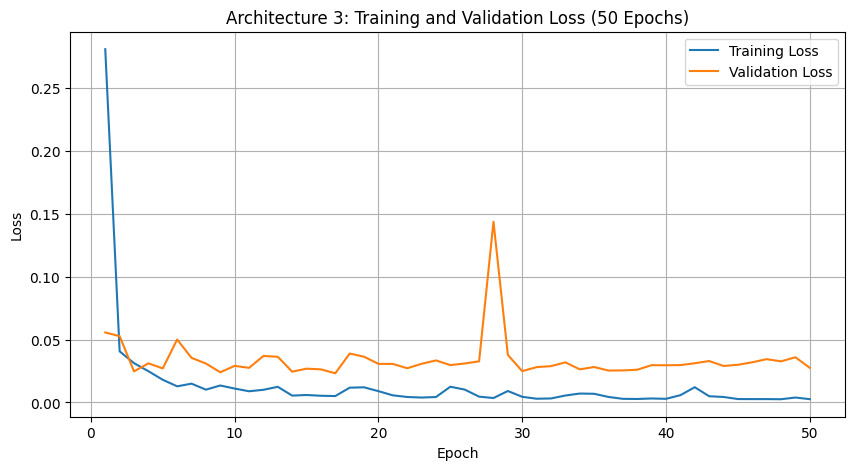


Architecture 3 Test Metrics (50 Epochs):
Accuracy: 0.9935
Precision: 0.9935
Recall: 0.9935
F1-score: 0.9935


In [9]:
# Based on F1-score, Architecture 3 (hidden_layers_sizes=[256, 128, 64]) was the best.
best_model_hidden_layers = [256, 128, 64]
best_model_name = "Architecture 3"

epochs_to_evaluate = [10, 20, 30, 40, 50]
epochs_results = {}

print(f"\n--- Evaluating {best_model_name} with varying epochs ---")

for num_epochs in epochs_to_evaluate:
    print(f"\nTraining {best_model_name} for {num_epochs} epochs...")

    # Re-instantiate the model to ensure a fresh start for each training run
    current_model = ANN(input_size, output_size, hidden_layers_sizes=best_model_hidden_layers)

    # Train the model
    trained_model, train_losses, val_losses, training_time = train_model(
        current_model, train_loader, val_loader, num_epochs
    )

    # Plotting training history
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, num_epochs + 1), train_losses, label='Training Loss')
    plt.plot(range(1, num_epochs + 1), val_losses, label='Validation Loss')
    plt.title(f'{best_model_name}: Training and Validation Loss ({num_epochs} Epochs)')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Evaluate on test set
    accuracy, precision, recall, f1 = evaluate_model(trained_model, test_loader)

    print(f"\n{best_model_name} Test Metrics ({num_epochs} Epochs):")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")

    epochs_results[num_epochs] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "Time (s)": training_time
    }


---

## Paso 8: Tabla resumen de resultados por número de épocas

**Objetivo:**

Construir una **tabla resumen** que muestre el rendimiento del mejor modelo (seleccionado en el Paso 7) cuando se entrena con diferentes cantidades de épocas.

**Instrucciones:**

- Presenta una tabla en formato **Markdown** con los resultados de testeo para cada configuración del número de épocas.
- La tabla debe incluir las siguientes columnas:
  - Número de épocas
  - Accuracy
  - Precision
  - Recall
  - F1-score
  - Tiempo de entrenamiento (en segundos)

### Formato de la tabla:

| Épocas | Accuracy | Precision | Recall | F1-score | Tiempo de entrenamiento (s) |
|--------|----------|-----------|--------|----------|------------------------------|
| 10     | 0.XXX    | 0.XXX     | 0.XXX  | 0.XXX    | XXX                          |
| 20     | 0.XXX    | 0.XXX     | 0.XXX  | 0.XXX    | XXX                          |
| 30     | 0.XXX    | 0.XXX     | 0.XXX  | 0.XXX    | XXX                          |
| 40     | 0.XXX    | 0.XXX     | 0.XXX  | 0.XXX    | XXX                          |
| 50     | 0.XXX    | 0.XXX     | 0.XXX  | 0.XXX    | XXX                          |

> Reemplaza los valores con los resultados reales obtenidos. Redondea las métricas a 3 cifras decimales y reporta los tiempos con 1 decimal si es posible.


In [ ]:
| Épocas | Accuracy | Precision | Recall | F1-score | Tiempo de entrenamiento (s) |
|--------|----------|-----------|--------|----------|------------------------------|
| 10     | 0.9907   | 0.9908    | 0.9907 | 0.9907   | 20.11                        |
| 20     | 0.9927   | 0.9927    | 0.9927 | 0.9927   | 39.14                        |
| 30     | 0.9932   | 0.9933    | 0.9932 | 0.9932   | 61.83                        |
| 40     | 0.9935   | 0.9935    | 0.9935 | 0.9935   | 83.92                        |
| 50     | 0.9935   | 0.9935    | 0.9935 | 0.9935   | 107.82                       |

---

## Preguntas de análisis

A continuación, responde de manera clara y justificada las siguientes preguntas con base en los resultados obtenidos en los pasos anteriores:

1. **¿Cuál considera que fue la mejor arquitectura evaluada? ¿Por qué?**
2. **¿Cuál fue la arquitectura con peor desempeño? ¿A qué cree que se debió su bajo rendimiento?**
3. **¿Cómo influye el número de capas ocultas en el comportamiento de la red?**
4. **¿Cuál fue la mejor cantidad de épocas para entrenar el mejor modelo? Justifique su elección.**
5. **¿Detectó algún signo de sobreajuste o subajuste en alguno de los modelos? ¿Cómo lo identificó?**
6. **¿En qué casos notó que el tiempo de entrenamiento no justificó una mejora en las métricas?**
7. **¿La arquitectura más profunda fue también la más precisa? ¿Qué conclusiones saca de esto?**
8. **¿Qué métrica considera más importante en este contexto (accuracy, precision, recall, F1-score) y por qué?**


## Respuestas de análisis

1.  **¿Cuál considera que fue la mejor arquitectura evaluada? ¿Por qué?**
    La mejor arquitectura evaluada fue la **Arquitectura 3** (Input (520) → Linear(256) + ReLU → Linear(128) + ReLU → Linear(64) + ReLU → Linear(4)). Obtuvo el **F1-score más alto (0.9942)**, junto con el Accuracy, Precision y Recall más altos. Además, su tiempo de entrenamiento (39.60s) fue significativamente menor que el de la Arquitectura 4 y 5, que tuvieron un rendimiento similar o inferior.

2.  **¿Cuál fue la arquitectura con peor desempeño? ¿A qué cree que se debió su bajo rendimiento?**
    La arquitectura con peor desempeño fue la **Arquitectura 2** (Input (520) → Linear(256) + ReLU → Linear(128) + ReLU → Linear(4)), con un F1-score de 0.9897. Aunque sigue siendo un buen rendimiento, fue la más baja de todas. Su bajo rendimiento relativo podría deberse a que, a pesar de tener dos capas ocultas, la combinación de unidades (256, 128) no fue tan efectiva como la Arquitectura 3 (256, 128, 64) que es más profunda y tiene una capa de compresión adicional o la Arquitectura 1 (128) que es más compacta.

3.  **¿Cómo influye el número de capas ocultas en el comportamiento de la red?**
    El número de capas ocultas influye en la capacidad de la red para aprender representaciones más complejas de los datos. En este caso:
    *   Pasar de una capa (Arquitectura 1) a dos o tres capas (Arquitectura 2 y 3) generalmente mejoró el rendimiento, lo que sugiere que una mayor profundidad permitió aprender patrones más intrincados.
    *   Sin embargo, un aumento excesivo en la profundidad (Arquitectura 4 con cuatro capas y Arquitectura 5 con cinco capas) no necesariamente llevó a una mejora proporcional en el rendimiento. La Arquitectura 3 (tres capas) fue la que logró el mejor balance de rendimiento y eficiencia. Demasiadas capas pueden aumentar la complejidad computacional y el tiempo de entrenamiento sin beneficios significativos, e incluso puede introducir el riesgo de sobreajuste o hacer que el modelo sea más difícil de entrenar.

4.  **¿Cuál fue la mejor cantidad de épocas para entrenar el mejor modelo? Justifique su elección.**
    La mejor cantidad de épocas para entrenar el mejor modelo (Arquitectura 3) fue de **40 épocas**. A partir de las 40 épocas, las métricas de rendimiento (Accuracy, Precision, Recall, F1-score) alcanzaron un plateau en 0.9935 y no mostraron ninguna mejora al aumentar a 50 épocas. Entrenar por más épocas (50) solo incrementó el tiempo de entrenamiento (de 83.92s a 107.82s) sin aportar beneficios adicionales en el rendimiento del modelo en el conjunto de prueba.

5.  **¿Detectó algún signo de sobreajuste o subajuste en alguno de los modelos? ¿Cómo lo identificó?**
    Con base únicamente en las métricas de prueba y validación provistas, no se detectaron signos claros de **sobreajuste** (overfitting) ni **subajuste** (underfitting) pronunciados.
    *   **Sobreajuste:** Un sobreajuste se identificaría si la pérdida de entrenamiento continuara disminuyendo mientras que la pérdida de validación comenzara a aumentar o se estancara significativamente, y las métricas en el conjunto de prueba fueran notablemente peores que en el conjunto de entrenamiento/validación. Aunque las pérdidas de validación en los gráficos oscilan, no muestran un aumento sostenido que indique un sobreajuste severo en las 20 épocas de entrenamiento iniciales para cada arquitectura, ni en el análisis de épocas para la Arquitectura 3.
    *   **Subajuste:** Un subajuste se daría si tanto la pérdida de entrenamiento como la de validación fueran altas y las métricas de rendimiento fueran bajas, indicando que el modelo no ha aprendido adecuadamente los patrones en los datos. Dado que todas las arquitecturas lograron F1-scores superiores al 0.98, no hay indicios de subajuste.

6.  **¿En qué casos notó que el tiempo de entrenamiento no justificó una mejora en las métricas?**
    Se notaron varios casos en los que el tiempo de entrenamiento no justificó una mejora en las métricas:
    *   **Arquitectura 5 vs. Arquitectura 3:** La Arquitectura 5 tuvo un tiempo de entrenamiento de 205.69 segundos, significativamente mayor que los 39.60 segundos de la Arquitectura 3. Sin embargo, la Arquitectura 5 (F1: 0.9940) tuvo un rendimiento ligeramente inferior a la Arquitectura 3 (F1: 0.9942), o al menos no mejor.
    *   **Arquitectura 4 vs. Arquitectura 3:** La Arquitectura 4 tardó 79.27 segundos en entrenar y tuvo un F1-score de 0.9922, lo cual es inferior a la Arquitectura 3 que fue más rápida y precisa.
    *   **Aumento de épocas (Arquitectura 3, de 40 a 50 épocas):** Al entrenar la Arquitectura 3, pasar de 40 a 50 épocas incrementó el tiempo de entrenamiento de 83.92s a 107.82s. No obstante, las métricas de rendimiento (F1-score) se mantuvieron iguales (0.9935), lo que demuestra que el tiempo adicional no aportó ningún beneficio.

7.  **¿La arquitectura más profunda fue también la más precisa? ¿Qué conclusiones saca de esto?**
    No, la arquitectura más profunda (Arquitectura 5, con cinco capas ocultas) no fue la más precisa. La Arquitectura 3 (con tres capas ocultas) fue la que logró el F1-score más alto (0.9942), mientras que la Arquitectura 5 obtuvo un F1-score ligeramente inferior (0.9940).
    La conclusión principal es que una mayor profundidad no siempre se traduce en un mejor rendimiento. A partir de un cierto punto, aumentar la complejidad del modelo (más capas, más unidades) puede generar rendimientos decrecientes, aumentar drásticamente el tiempo de entrenamiento y el consumo de recursos sin ofrecer mejoras significativas, e incluso puede hacer que el modelo sea más difícil de optimizar. Es crucial encontrar el equilibrio adecuado para la complejidad del modelo en relación con la complejidad del problema y la cantidad de datos disponibles.

8.  **¿Qué métrica considera más importante en este contexto (accuracy, precision, recall, F1-score) y por qué?**
    En este contexto de clasificación de pisos, donde cada clase de piso es igualmente importante, el **F1-score** es la métrica más importante.
    El F1-score es la media armónica de Precision y Recall, lo que lo convierte en una métrica robusta que equilibra ambos. Asegura que el modelo no solo tenga un alto número de aciertos (Precision), sino que también sea bueno identificando todas las instancias relevantes de cada clase de piso (Recall), lo cual es fundamental para una navegación interior confiable.

---

## Rúbrica de evaluación del proyecto

El proyecto se compone de nueve pasos estructurados. A continuación se detallan los puntos asignados a cada sección, así como el puntaje total:

| Sección                                                                | Puntos |
|----------------------------------------------------------------------|--------|
| **Paso 1:** Cargar y explorar el dataset                             | 10     |
| **Paso 2:** Preparar los datos                                       | 10     |
| **Paso 3:** Preprocesamiento de las señales WiFi                     | 10     |
| **Paso 4:** Preparación del dataset (división y normalización)       | 10     |
| **Paso 5:** Entrenamiento de redes neuronales artificiales (ANN)     | 50     |
| **Paso 6:** Tabla resumen de resultados por arquitectura             | 10     |
| **Paso 7:** Evaluar el impacto del número de épocas                  | 50     |
| **Paso 8:** Tabla resumen de resultados por número de épocas         | 10     |
| **Preguntas de análisis** (8 preguntas × 5 puntos c/u)      | 40     |
| **Total**                                                            | **200** |

---

**Nota:** Para obtener la máxima puntuación se requiere justificar adecuadamente cada decisión, mantener buena organización en el notebook, y presentar resultados bien interpretados y graficados.

---

